# Decision Tree Classifier - Baseline Model
In this notebook, we load the preprocessed weather dataset and train a baseline Decision Tree Classifier. We evaluate the model's accuracy on the training and validation sets, visualize the top branches of the tree, and analyze feature importances.


### 1. Load Processed Data
We import the required libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and load the preprocessed training inputs and targets.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_inputs = pd.read_csv('../data/processed/train_inputs.csv')
train_targets = pd.read_csv('../data/processed/train_targets.csv')

### 2. Import DecisionTreeClassifier
We import the decision tree classifier from `sklearn.tree`.


In [2]:
from sklearn.tree import DecisionTreeClassifier

### 3. Initialize and Fit Model
We instantiate a baseline `DecisionTreeClassifier` with `random_state=42` and fit it to our training data.


In [3]:
model = DecisionTreeClassifier(random_state=42)

model.fit(train_inputs, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4. Generate Predictions
We predict the labels for the training set and display the distribution of predicted outcomes.


In [4]:
train_predictions = model.predict(train_inputs)
print(train_predictions)
print(pd.value_counts(train_predictions))

['No' 'No' 'No' ... 'No' 'No' 'No']
No     76707
Yes    22281
Name: count, dtype: int64


C:\Users\mst\AppData\Local\Temp\ipykernel_12456\3938302021.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(train_predictions))


### 5. Import Metrics
We import `accuracy_score` and `confusion_matrix` from `sklearn.metrics` to assess model performance.


In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix

### 6. Calculate Training Accuracy
We compute the accuracy score on the training set. Since we did not set constraints like max depth, we expect a near-perfect accuracy (overfitting).


In [6]:
accuracy = accuracy_score(train_targets, train_predictions)
print(accuracy)

0.9999797955307714


### 7. Calculate Prediction Probabilities
We output the probability estimates for each class in the training set.


In [7]:
train_probabilities = model.predict_proba(train_inputs)
print(train_probabilities)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


### 8. Evaluate on Validation Set
We load the processed validation dataset and compute the baseline model accuracy. Comparing this to training accuracy will show if the model is overfitting.


In [8]:
validation_inputs = pd.read_csv('../data/processed/validation_inputs.csv')
validation_targets = pd.read_csv('../data/processed/validation_targets.csv')

model.score(validation_inputs, validation_targets)

0.7929893796065232

### 9. Check Baseline Distribution
We verify the class distribution of `RainTomorrow` in the validation set to compare accuracy against a naive baseline prediction (e.g., predicting 'No' every time).


In [9]:
validation_targets.value_counts() /len(validation_targets)

RainTomorrow
No              0.788289
Yes             0.211711
Name: count, dtype: float64

### 10. Import Tree Visualizers
We import `plot_tree` and `export_text` to visualize and understand the decisions made by the tree.


In [10]:
from sklearn.tree import plot_tree, export_text

### 11. Plot Decision Tree
We plot the first few levels (`max_depth=3`) of the decision tree to inspect the splits.


[Text(0.5, 0.9, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]\nclass = 0'),
 Text(0.25, 0.7, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]\nclass = 0'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Sunshine <= 0.532\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]\nclass = 0'),
 Text(0.0625, 0.3, 'Pressure3pm <= 0.57\ngini = 0.363\nsamples = 12620\nvalue = [9618, 3002]\nclass = 0'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'Humidity3pm <= 0.513\ngini = 0.153\nsamples = 56632\nvalue = [51920, 4712]\nclass = 0'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Humidity3pm <= 0.513\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]\nclass = 0'),
 Text(0.3125, 0.3, 'WindGustSpeed <= 0.318\ngini = 0.293\nsamples = 4299\nvalue = [3531, 768]\nclass = 0'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  

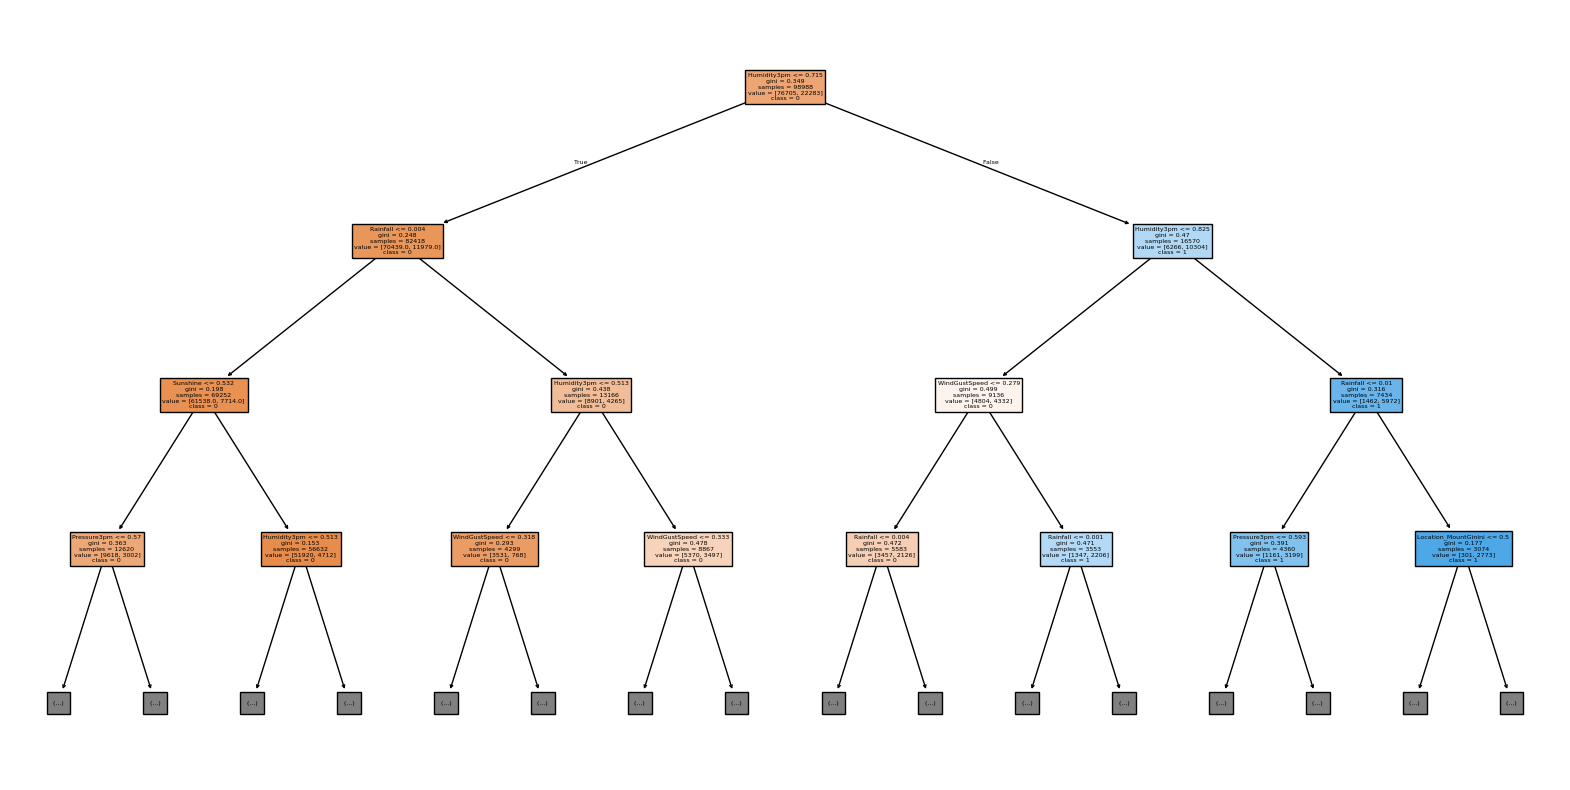

In [11]:
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=train_inputs.columns, class_names=['0', '1'], max_depth=3)

### 12. Export Tree Rules as Text
We export the decision rules of the tree in text format for a structured rule-by-rule view.


In [12]:
tree_text = export_text(model, feature_names=list(train_inputs.columns))
print(tree_text)

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.57
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure9am <= 0.47
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure9am >  0.47
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated

### 13. Inspect Feature Importances
We inspect the array of raw feature importance scores computed by the model.


In [13]:
model.feature_importances_

array([3.59693809e-02, 3.12813242e-02, 5.85936415e-02, 2.27964832e-02,
       4.94950179e-02, 5.53301667e-02, 2.85301029e-02, 3.12159266e-02,
       3.88292210e-02, 2.61880735e-01, 3.42357497e-02, 6.14596462e-02,
       1.37900267e-02, 1.75962179e-02, 3.41056992e-02, 2.98176014e-02,
       2.07817897e-03, 2.14987613e-03, 1.50143313e-03, 6.40117134e-04,
       1.58888448e-03, 1.11721152e-03, 7.00504227e-04, 1.77002115e-03,
       1.33809912e-03, 1.51957686e-03, 8.83429996e-04, 2.39168857e-03,
       1.68951308e-03, 2.05586876e-04, 1.14392097e-03, 1.65496962e-03,
       5.03399284e-04, 8.17173668e-04, 1.36128777e-03, 8.97854563e-04,
       1.03752527e-03, 7.44440460e-04, 1.78286516e-03, 2.05734177e-03,
       2.72778717e-04, 6.32810071e-04, 1.47394157e-03, 1.35126933e-03,
       1.33826758e-03, 9.17956348e-04, 6.13692039e-04, 1.46476875e-03,
       1.17135375e-03, 2.01909430e-03, 9.64454318e-04, 1.80419066e-03,
       1.09569479e-03, 1.15531312e-03, 1.24389290e-03, 5.12884974e-04,
      

### 14. Analyze Top Features
We create a DataFrame of features and their importance scores, then display the top 10 most influential features.


In [14]:
from httpx import head

importance_df = pd.DataFrame({'feature': train_inputs.columns, 'importance': model.feature_importances_})
importance_df.head(10).sort_values(by='importance', ascending=False)    

,feature,importance
9,Humidity3pm,0.261881
2,Rainfall,0.058594
5,WindGustSpeed,0.055330
4,Sunshine,0.049495
8,Humidity9am,0.038829
0,MinTemp,0.035969
1,MaxTemp,0.031281
7,WindSpeed3pm,0.031216
6,WindSpeed9am,0.028530
3,Evaporation,0.022796


### 15. Plot Feature Importances
We plot a bar chart using `seaborn` to visually compare the importances of the top 10 features.


<Axes: xlabel='importance', ylabel='feature'>

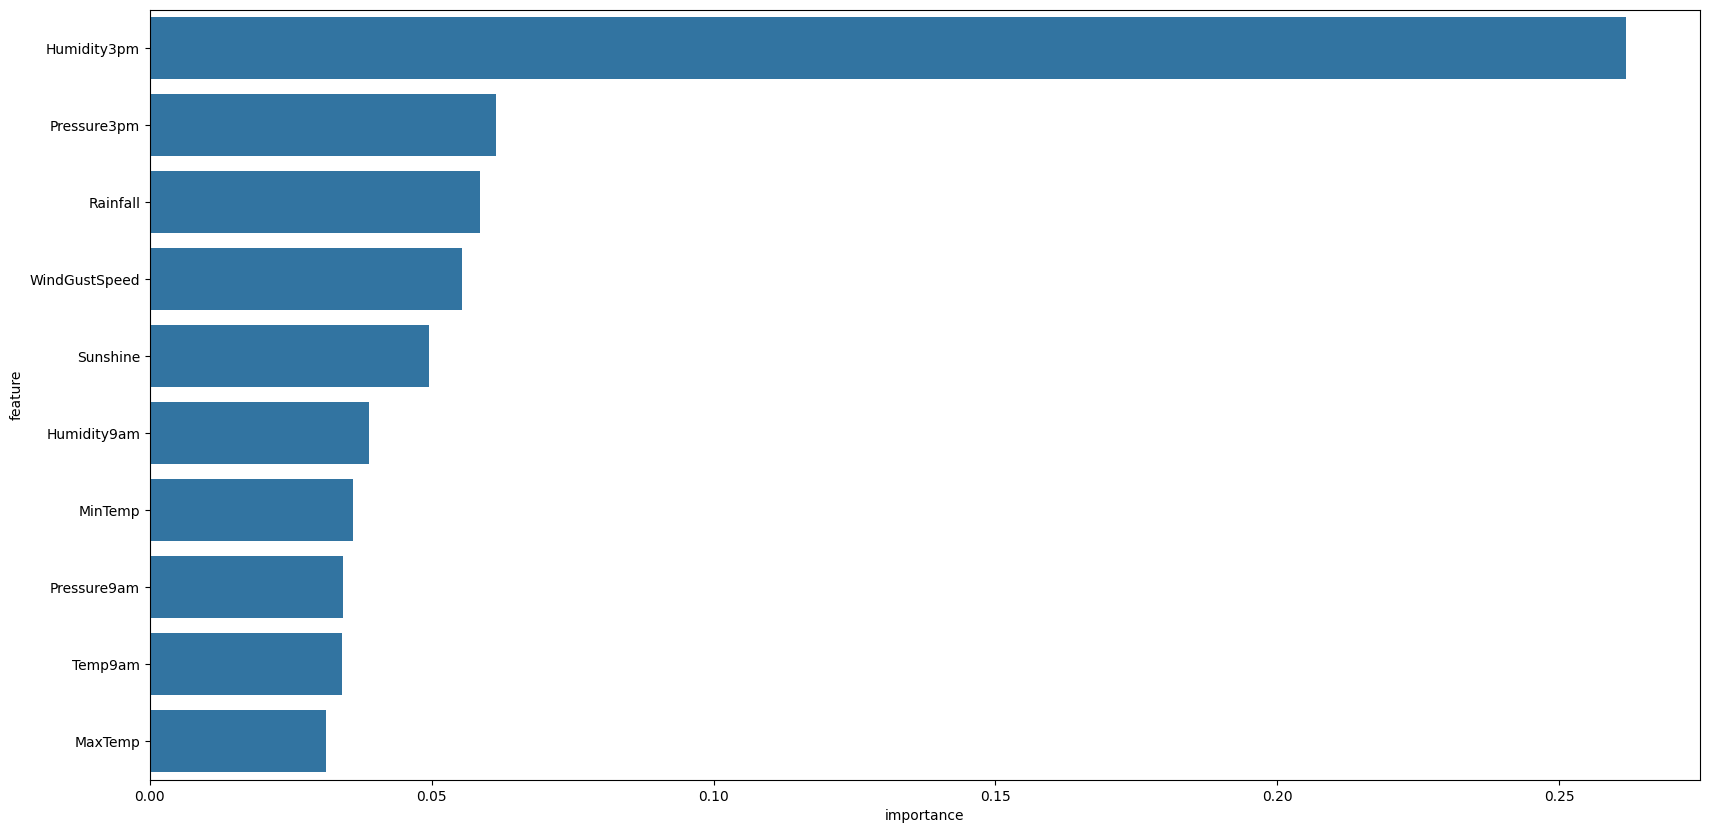

In [15]:
plt.figure(figsize=(20,10))
sns.barplot(x='importance', y='feature', data=importance_df.sort_values(by='importance', ascending=False).head(10))